<a href="https://colab.research.google.com/github/Raksh1707/Naturalproject/blob/main/nlp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd  # loading data
import numpy as np
import re           # regular expressions for cleaning the data
import nltk
import matplotlib.pyplot as plt  #visualization
from nltk.corpus import stopwords  #to remove verbs unwanted words
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud


# Download required NLTK files
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

#display first few rows
print("Customer Reviews Dtaset")
print(df.head())

Customer Reviews Dtaset
                                              Review
0  The product quality is excellent and delivery ...
1       Very bad packaging and the item was damaged.
2       Customer service was helpful and responsive.
3  The delivery was delayed and support team did ...
4                  Amazing product. Worth the money.


In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    # Convert to lowercase
    text = text.lower()
    print('lower case', text)

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    print('special character', text)

    # Tokenization
    words = word_tokenize(text)
    print('tokenization', words)

    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    print('stopwords',words)

    #join wors again
    cleaned_text=" ".join(words)

    return cleaned_text


#apply cleaning function
df['Cleaned_Review']=df['Review'].apply(clean_text)

print("\nCleanedReview")
print(df[['Review','Cleaned_Review']])

lower case the product quality is excellent and delivery was very fast.
special character the product quality is excellent and delivery was very fast
tokenization ['the', 'product', 'quality', 'is', 'excellent', 'and', 'delivery', 'was', 'very', 'fast']
stopwords ['product', 'quality', 'excellent', 'delivery', 'fast']
lower case very bad packaging and the item was damaged.
special character very bad packaging and the item was damaged
tokenization ['very', 'bad', 'packaging', 'and', 'the', 'item', 'was', 'damaged']
stopwords ['bad', 'packaging', 'item', 'damaged']
lower case customer service was helpful and responsive.
special character customer service was helpful and responsive
tokenization ['customer', 'service', 'was', 'helpful', 'and', 'responsive']
stopwords ['customer', 'service', 'helpful', 'responsive']
lower case the delivery was delayed and support team did not respond.
special character the delivery was delayed and support team did not respond
tokenization ['the', 'delivery'

In [ ]:
# Step 4: Sentiment Analysis

sia = SentimentIntensityAnalyzer()

def analyze_sentiment(review):

    score = sia.polarity_scores(review)

    compound = score['compound']

    if compound >= 0.05:
        return "Positive"

    elif compound <= -0.05:
        return "Negative"

    else:
        return "Neutral"


#apply sentiment analysis
df['Sentiment']=df['Cleaned_Review'].apply(analyze_sentiment)

print("\nSentiment Analysis Results")
print(df[['Review','Sentiment']])


Sentiment Analysis Results
                                              Review Sentiment
0  The product quality is excellent and delivery ...  Positive
1       Very bad packaging and the item was damaged.  Negative
2       Customer service was helpful and responsive.  Positive
3  The delivery was delayed and support team did ...  Positive
4                  Amazing product. Worth the money.  Positive
5      Poor quality product and terrible experience.  Negative
6                  Fast shipping and good packaging.  Positive
7        The product stopped working after two days.  Negative
8               Excellent service and great quality.  Positive
9            Late delivery and bad customer support.  Negative


In [ ]:
from collections import Counter

# Combine all cleaned reviews
all_words = " ".join(df['Cleaned_Review'])

# Convert text into list of words
word_list = all_words.split()

# Count word frequency
word_freq = Counter(word_list)

# Display top 10 keywords
print("\nTop 10 Common Keywords")
print(word_freq.most_common(10))


Top 10 Common Keywords
[('product', 4), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


In [ ]:
#Step 6: Identify Common Complaints

negative_reviews = df[df['Sentiment'] == 'Negative']

negative_words = " ".join(negative_reviews['Cleaned_Review'])

negative_word_list = negative_words.split()

complaint_freq = Counter(negative_word_list)

print("\nMost Common Complaint Keywords")
print(complaint_freq.most_common(10))


Most Common Complaint Keywords
[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


In [ ]:
sentiment_counts = df['Sentiment'].value_counts()
sentiment_counts

,count
Sentiment,
Positive,6
Negative,4


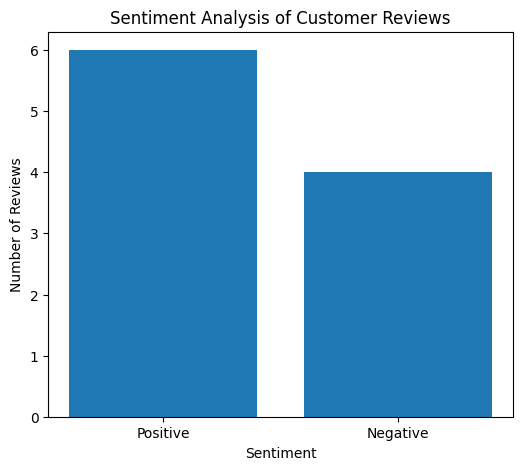

In [ ]:
#Step 7: Visualization - Sentiment Count

sentiment_counts = df['Sentiment'].value_counts()  # it will give

plt.figure(figsize=(6,5))

plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.title("Sentiment Analysis of Customer Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

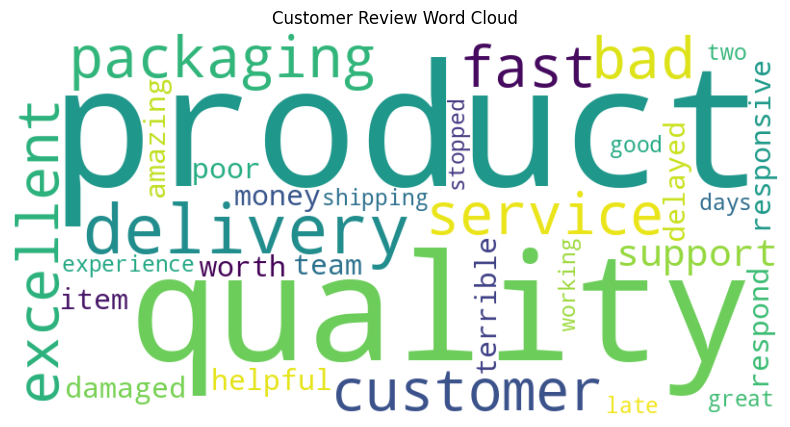

In [ ]:
#step 8 generate word cloud

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.title("Customer Review Word Cloud")
plt.show()